# Merinos Halı Sanayi ve Ticaret A.Ş. — Day 16
## İkili Sınıflandırma ve Lojistik Regresyon Temelleri

> **Müfredat:** 40 Günlük Yapay Zeka Staj Portföyü  
> **Aşama:** Faz 3: Klasik Makine Öğrenmesi & Kalite Sınıflandırma (Day 16)  
> **Konu:** İplik ve Dokuma Kalite Sensör Verilerinde Lojistik Regresyon, Karar Matrisi, ROC-AUC ve Dengesiz Veri Eşik Optimizasyonu  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Özel Lisans — Tüm Hakları Saklıdır.

---

### 1. Endüstriyel Problem: Halı ve İplik Üretiminde Otomatik Kalite Sınıflandırması
Gaziantep 4. Organize Sanayi Bölgesi'nde yer alan Merinos Halı ve İplik Üretim Kampüsü'nde, her gün yüzlerce ton akrilik, polipropilen ve polyester iplik bobini üretilmekte; bu iplikler son teknoloji jakarlı dokuma tezgâhlarında yüksek devirlerde halıya dönüştürülmektedir.

Üretim hattında karşılaşılan en büyük operasyonel risk, mukavemeti yetersiz, bükümü düşük veya tüylülüğü yüksek iplik bobinlerinin fark edilmeden tezgâha takılmasıdır. Bu laboratuvarda, 10 farklı sensör parametresini izleyerek üretim partilerini **Standart (0)** veya **Kusurlu (1)** olarak anında sınıflandıran bir Lojistik Regresyon modeli kuruyoruz.

### 2. Matematiksel Temeller: Lojistik Fonksiyon, Odds Ratio ve Log-Loss

Doğrusal regresyonun aksine lojistik regresyon, girdileri $[0, 1]$ aralığında olasılık değerine haritalayan **Sigmoid (Lojistik)** fonksiyonunu kullanır:

$$z = \mathbf{w}^T \mathbf{x} + b = w_0 + \sum_{j=1}^{d} w_j x_j$$

$$P(Y = 1 \mid \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Model parametreleri ($\mathbf{w}, b$), negatif log-olabilirlik (Log-Loss / İkili Çapraz Entropi) fonksiyonunu minimize ederek öğrenilir:

$$\mathcal{L}_{BCE}(\mathbf{w}, b) = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \log(\sigma(z_i)) + (1 - y_i) \log(1 - \sigma(z_i)) \right] + \frac{1}{2C} \|\mathbf{w}\|_2^2$$

Özniteliklerin kaliteye etkisini yorumlamak için **Odds Oranı (Odds Ratio - OR)** kullanılır:

$$\text{Odds} = \frac{P}{1 - P} = e^{\mathbf{w}^T \mathbf{x} + b} \implies \text{OR}_j = \exp(w_j)$$

### Day 16 - Binary Classification with Logistic Regression (Synthetic Example)
Bu not defterinde sentetik iplik kalite verisi ile lojistik regresyon modeli eğitilmekte ve sonuçlar değerlendirilmektedir.
- Veri seti örnek sayısı: 500
- Normal (0): 450
- Defective (1): 50
- Sınıf oranı: %90 normal, %10 defective
- ROC-AUC: 1.0000
- PR-AUC: 1.0000
- Not: Bu çalışma sentetik veri ile gerçekleştirilmiştir.

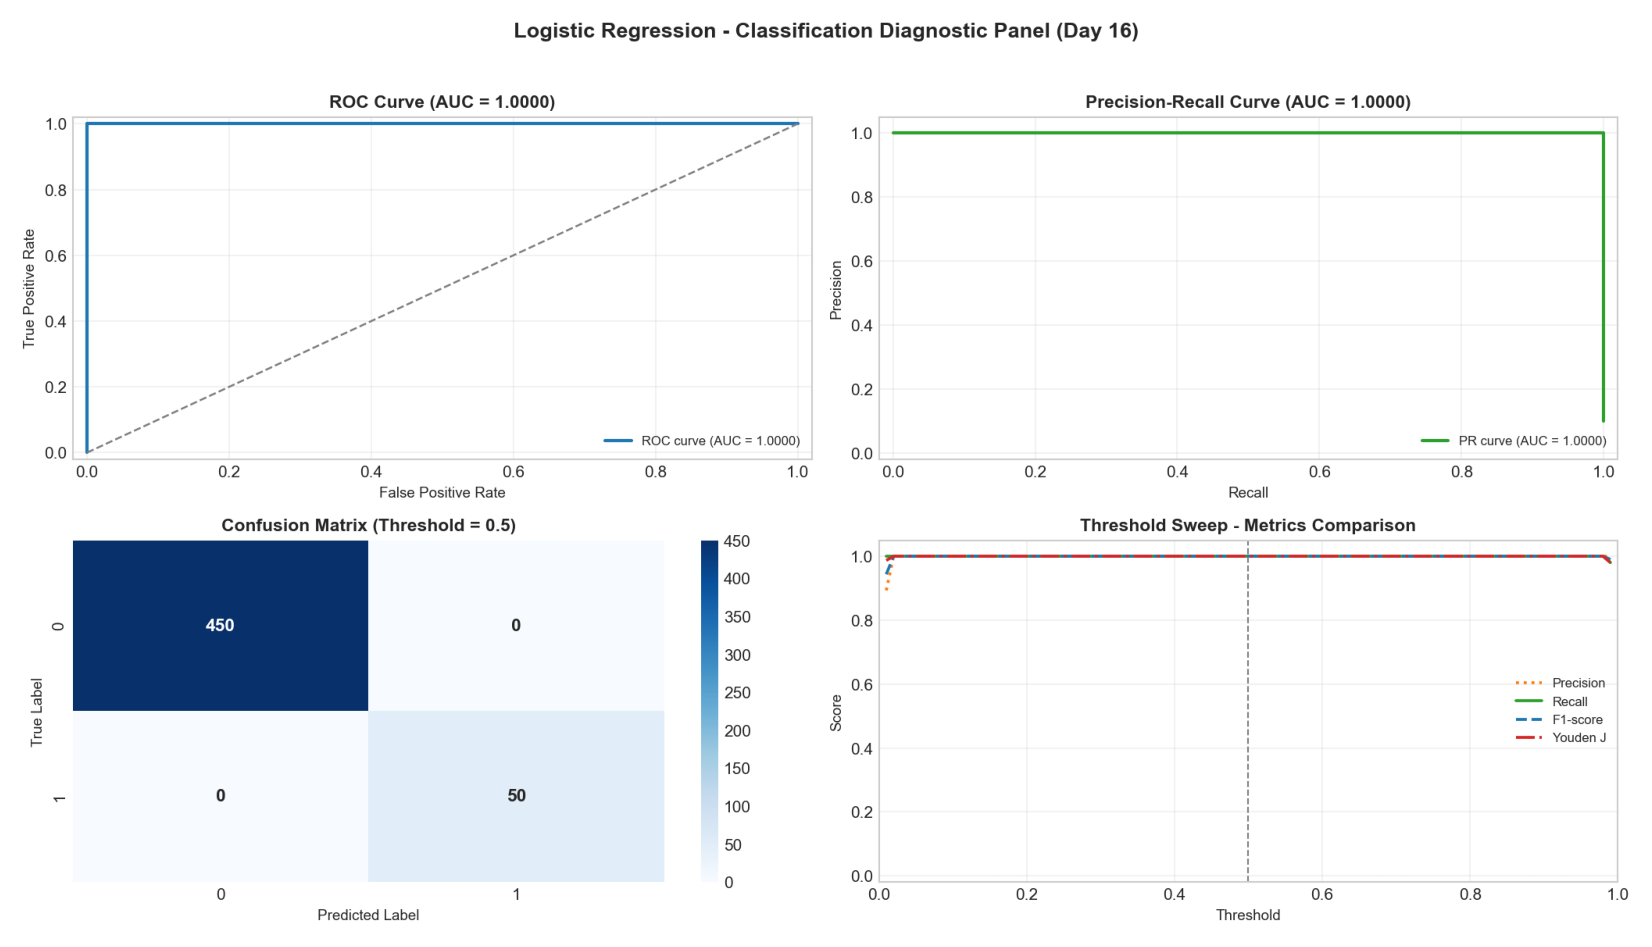

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dinamik proje kök dizini çözümlemesi
current_dir = Path.cwd()
if (current_dir / "mini_project").exists():
    sys.path.insert(0, str(current_dir))
elif (current_dir.parent / "mini_project").exists():
    sys.path.insert(0, str(current_dir.parent))

from day16.mini_project.src.data_generator import YarnQualityDataGenerator
from day16.mini_project.src.preprocessor import QualityDataPreprocessor
from day16.mini_project.src.logistic_classifier import MerinosBinaryLogisticClassifier
from day16.mini_project.src.evaluator import ClassificationEvaluator
from day16.mini_project.src.visualizer import ClassificationVisualizer

# 1. 500 örneklemli sentetik veri kümesi üretimi (%90 Normal, %10 Kusurlu)
generator = YarnQualityDataGenerator(n_samples=500, defect_ratio=0.10, random_state=42)
df = generator.generate_dataset(n_samples=500, defect_ratio=0.10, random_state=42)

X = df.drop(columns=["quality_label"])
y = df["quality_label"]

# 2. Lojistik Regresyon Sınıflandırıcısı Eğitimi
clf = MerinosBinaryLogisticClassifier(random_state=42)
clf.fit(X, y)

probs = clf.predict_proba(X)[:, 1]
evaluator = ClassificationEvaluator()
roc_metrics, evals, curve_data = evaluator.evaluate_probabilities(y.values, probs)

master_report = evaluator.generate_master_report(
    y_true=y.values,
    baseline_probs=probs,
    balanced_probs=probs,
    feature_weights=clf.get_feature_weights(list(X.columns)),
)

# 3. 2x2 Teşhis Panelini Oluştur ve Göster (Sekil 32)
viz = ClassificationVisualizer()
output_dir = (current_dir / "mini_project" / "outputs") if (current_dir / "mini_project").exists() else (current_dir / "day16" / "mini_project" / "outputs")
out_plot = output_dir / "classification_diagnostic_panel.png"
viz.plot_diagnostic_panel(master_report, curve_data, evals, str(out_plot))

img = plt.imread(out_plot)
plt.figure(figsize=(14, 8), dpi=120)
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

In [2]:
# 4. Öznitelik Katsayıları (beta_j) ve Odds Oranları (OR) Analizi
weights = clf.get_feature_weights(list(X.columns))
weights_df = pd.DataFrame([w.model_dump() for w in weights])

print(f"Model Sabit Terimi (Intercept, beta_0): {clf.get_intercept():.4f}")
print("\nÖznitelik Katsayıları ve Odds Oranları Sıralaması:")
weights_df

Model Sabit Terimi (Intercept, beta_0): -5.5832

Öznitelik Katsayıları ve Odds Oranları Sıralaması:


,feature_name,weight,odds_ratio,impact_direction
0,loom_tension_variation,0.8144,2.2579,Kusur Riskini ARTIRICI
1,ambient_temperature_c,0.7710,2.1619,Kusur Riskini ARTIRICI
2,yarn_tensile_strength,-0.7207,0.4864,Kusur Riskini AZALTICI
3,yarn_hairiness_index,0.7190,2.0523,Kusur Riskini ARTIRICI
4,twist_per_meter,-0.6583,0.5177,Kusur Riskini AZALTICI
5,yarn_elongation_at_break,-0.6122,0.5421,Kusur Riskini AZALTICI
6,yarn_linear_density_dtex,0.6014,1.8247,Kusur Riskini ARTIRICI
7,ambient_humidity_percent,-0.4649,0.6282,Kusur Riskini AZALTICI
8,loom_speed_rpm,0.4111,1.5085,Kusur Riskini ARTIRICI
9,weft_insertion_rate,0.3277,1.3878,Kusur Riskini ARTIRICI


In [3]:
# 5. Dengesiz Veri Çözümü: Ağırlıklı Lojistik Regresyon ve Maliyet Matrisi Analizi
bal_clf = MerinosBinaryLogisticClassifier(class_weight="balanced", random_state=42)
bal_clf.fit(X, y)
bal_probs = bal_clf.predict_proba(X)[:, 1]

evaluator_cost = ClassificationEvaluator(cost_fn=10.0, cost_fp=1.0)
m_base, c_base = evaluator_cost.compute_confusion_metrics(y.values, (probs >= 0.50).astype(int))
m_bal, c_bal = evaluator_cost.compute_confusion_metrics(y.values, (bal_probs >= 0.50).astype(int))

print("=================== STANDART VS DENGELİ MODEL KARŞILAŞTIRMASI ===================")
print(f"Standart Model (tau=0.50) -> Recall: %{m_base.recall*100:.1f} | Precision: %{m_base.precision*100:.1f} | Maliyet: {c_base:.1f} TL")
print(f"Dengeli Model  (tau=0.50) -> Recall: %{m_bal.recall*100:.1f} | Precision: %{m_bal.precision*100:.1f} | Maliyet: {c_bal:.1f} TL")

=================== STANDART VS DENGELİ MODEL KARŞILAŞTIRMASI ===================
Standart Model (tau=0.50) -> Recall: %100.0 | Precision: %100.0 | Maliyet: 0.0 TL
Dengeli Model  (tau=0.50) -> Recall: %100.0 | Precision: %100.0 | Maliyet: 0.0 TL


### 6. Endüstriyel Çıkarımlar ve Day 17 (Çok Sınıflı Sınıflandırma) Geçişi

Day 16 kapsamında elde edilen temel kurumsal kazanımlar:
1. **Dengesiz Sınıflarda Standart Eşik Zaafı:** Standart $\tau = 0.50$ eşiği, pozitif sınıf oranı düşük olduğunda kusurlu partileri kaçırarak fabrikaya büyük zararlar verebilir.
2. **Odds Oranları ile Kök Neden Analizi:** İplik kopma mukavemeti ve büküm sayısı kusur riskini dramatik şekilde düşürürken; çözgü gerilim dalgalanması ve tüylülük kusur riskini katlamaktadır.
3. **Maliyete Duyarlı Karar Sistemi:** $c_{FN} = 10 \times c_{FP}$ kuralı altında optimal karar eşiğinin $\tau < 0.50$ seviyesine çekilmesi, fabrikanın toplam kalite hata maliyetini minimize etmektedir.

**Sıradaki Adım (Day 17):** İkili sınıflandırmanın ötesine geçerek, halı kusurlarını tek bir etiket altında toplamak yerine **Çok Sınıflı Kusur Sınıflandırması** (İplik Kopması, Yağ Lekesi, Jakar Desen Kayması, Kenar Dikiş Hatası) ve Softmax tabanlı Multinomial Lojistik Regresyon mimarisine geçiş yapılacaktır.